In [425]:
from torch.utils import data
from torch.utils.data import DataLoader,Dataset
import pandas as pd
import torch.nn as nn
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

covid_data= pd.read_csv('covid.train.csv')
covid_data.head()


,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428


In [426]:
covid_data.columns

Index(['id', 'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'FL', 'GA', 'ID', 'IL',
       'IN', 'IA', 'KS', 'KY', 'LA', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'NE',
       'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'TX',
       'UT', 'VA', 'WA', 'WV', 'WI', 'cli', 'ili', 'hh_cmnty_cli',
       'nohh_cmnty_cli', 'wearing_mask', 'travel_outside_state',
       'work_outside_home', 'shop', 'restaurant', 'spent_time', 'large_event',
       'public_transit', 'anxious', 'depressed', 'felt_isolated',
       'worried_become_ill', 'worried_finances', 'tested_positive', 'cli.1',
       'ili.1', 'hh_cmnty_cli.1', 'nohh_cmnty_cli.1', 'wearing_mask.1',
       'travel_outside_state.1', 'work_outside_home.1', 'shop.1',
       'restaurant.1', 'spent_time.1', 'large_event.1', 'public_transit.1',
       'anxious.1', 'depressed.1', 'felt_isolated.1', 'worried_become_ill.1',
       'worried_finances.1', 'tested_positive.1', 'cli.2', 'ili.2',
       'hh_cmnty_cli.2', 'nohh_cmnty_cli.2', 'wea

In [427]:
def get_device():
    ''' Get device (if GPU is available, use GPU) '''
    return 'cuda' if torch.cuda.is_available() else 'cpu'

def plot_learning_curve(loss_record, title=''):
    ''' Plot learning curve of your DNN (train & dev loss) '''
    total_steps = len(loss_record['train'])
    x_1 = range(total_steps)
    x_2 = x_1[::len(loss_record['train']) // len(loss_record['dev'])]
    figure(figsize=(6, 4))
    plt.plot(x_1, loss_record['train'], c='tab:red', label='train')
    plt.plot(x_2, loss_record['dev'], c='tab:cyan', label='dev')
    plt.ylim(0.0, 5.)
    plt.xlabel('Training steps')
    plt.ylabel('MSE loss')
    plt.title('Learning curve of {}'.format(title))
    plt.legend()
    plt.show()


def plot_pred(dv_set, model, device, lim=35., preds=None, targets=None):
    ''' Plot prediction of your DNN '''
    if preds is None or targets is None:
        model.eval()
        preds, targets = [], []
        for x, y in dv_set:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
        preds = torch.cat(preds, dim=0).numpy()
        targets = torch.cat(targets, dim=0).numpy()

    figure(figsize=(5, 5))
    plt.scatter(targets, preds, c='r', alpha=0.5)
    plt.plot([-0.2, lim], [-0.2, lim], c='b')
    plt.xlim(-0.2, lim)
    plt.ylim(-0.2, lim)
    plt.xlabel('ground truth value')
    plt.ylabel('predicted value')
    plt.title('Ground Truth v.s. Prediction')
    plt.show()

In [428]:

# 1.定义数据集 
class COVID19Dataset(Dataset):
    def __init__(self,file_path,mode='train',target_only=False) -> None:
        super().__init__()
        self.mode = mode

        data = pd.read_csv(file_path)
        data = data.values[:, 1:].astype(float)  # pandas已跳过表头，直接用.values

        if not target_only:
            feats = list(range(93))
        else:
            feats = list(range(40))+[57,75]


        if mode == 'test':
            data = data[:,feats]
            self.data = torch.FloatTensor(data)
        else:
            target = data[:,-1]
            data = data[:,feats]
            if mode == 'train':
                feather = [i for i in range(len(data)) if i % 10 != 0]
            elif mode == 'dev':
                feather = [i for i in range(len(data)) if i % 10 == 0]

            self.data = torch.FloatTensor(data[feather])
            self.target = torch.FloatTensor(target[feather])

        self.data[:, 40:] = \
        (self.data[:, 40:] - self.data[:, 40:].mean(dim=0, keepdim=True)) \
        / self.data[:, 40:].std(dim=0, keepdim=True)
        
        self.dim = self.data.shape[1]

        print('Finished reading the {} set of COVID19 Dataset ({} samples found, each dim = {})'
              .format(mode,len(self.data),self.dim))
        
    def __getitem__(self,index):
        if self.mode in ['train','dev']:
            return self.data[index],self.target[index]
        else:
            return self.data[index]
    
    def __len__(self):
        return len(self.data)
            


    


In [429]:
def get_dataloader(path,mode,batch_size,n_jobs=0,target_only=True):
    dataset = COVID19Dataset(path,mode=mode,target_only=target_only)
    dataloader = DataLoader(
        dataset,batch_size,
        shuffle=(mode == 'train'),drop_last=False,
        num_workers=n_jobs,pin_memory=True
    )
    return dataloader

In [430]:
# 2.定义模型
class NeuralNet(nn.Module):
    def __init__(self,input_dim):
        super(NeuralNet,self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )


    def forward(self,x):
        return self.net(x).squeeze(1)
    


In [431]:
# 3.定义损失函数
def get_criterion() -> nn.MSELoss:
    return nn.MSELoss(reduction='mean')
    


In [432]:
# 4.定义优化器
def get_optimizer(model,lr,weight_decay) -> torch.optim.Adam:
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


In [433]:
# 5.定义设备
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    

In [434]:
# 6.定义评估函数
def dev(dv_set,model,device):
    model.eval()
    total_loss = 0
    criterion = get_criterion()
    for x,y in dv_set:
        x,y = x.to(device),y.to(device)
        with torch.no_grad():
            pred = model(x)
            mse_loss = criterion(pred,y)
        total_loss += mse_loss.detach().cpu().item() * len(x)
    total_loss = total_loss / len(dv_set.dataset)
    return total_loss



In [435]:
# 7.定义训练函数
def train(tr_set,dv_set,model,config,device):
    max_epochs = config['max_epochs']
    batch_size = config['batch_size']
    lr = config['optim_hparas']['lr']
    weight_decay = config['optim_hparas']['weight_decay']


    optimizer = get_optimizer(model,lr,weight_decay)

    min_mse = 1000
    loss_record = {'train':[],'dev':[]}
    early_stop_cnt = 0
    epoch = 0
    criterion= get_criterion()

    while epoch < max_epochs:
        model.train()
        for x,y in tr_set:
            x,y = x.to(device),y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred,y)
            loss.backward()
            optimizer.step()
            loss_record['train'].append(loss.detach().cpu().item())

        dev_mse = dev(dv_set,model,device)
        if dev_mse < min_mse:
            min_mse = dev_mse
            print('Saving model (epoch = {:4d}, loss = {:.4f})'
                  .format(epoch+1,min_mse))
            torch.save(model.state_dict(),config['save_path'])
            early_stop_cnt = 0
        else:
            early_stop_cnt += 1
            
        loss_record['dev'].append(dev_mse)
        epoch += 1
        if early_stop_cnt > config['early_stop']:
            print('Early stopping at epoch {:4d}...'.format(epoch))
            break
    
    return min_mse,loss_record

    
        

In [436]:
# 8.定义测试函数
def test(tt_set,model,device):
    model.eval()
    preds = []
    for x in tt_set:
        x = x.to(device)
        with torch.no_grad():
            pred = model(x)
            preds.append(pred.detach().cpu())
    preds = torch.cat(preds,dim=0).numpy()
    return preds

In [437]:
tr_set = get_dataloader(config['file_path'], 'train', config['batch_size'],)
dv_set = get_dataloader(config['file_path'], 'dev', config['batch_size'],)
tt_set = get_dataloader('covid.test.csv', 'test', config['batch_size'],)




Finished reading the train set of COVID19 Dataset (2430 samples found, each dim = 42)
Finished reading the dev set of COVID19 Dataset (270 samples found, each dim = 42)
Finished reading the test set of COVID19 Dataset (893 samples found, each dim = 42)


In [438]:
model = NeuralNet(tr_set.dataset.dim).to(config['device'])


In [439]:
os.makedirs('models',exist_ok=True)

In [440]:
model_loss, model_loss_record = train(tr_set, dv_set, model, config, config['device'])

Saving model (epoch =    1, loss = 325.3678)
Saving model (epoch =    2, loss = 325.3384)
Saving model (epoch =    3, loss = 325.3091)
Saving model (epoch =    4, loss = 325.2797)
Saving model (epoch =    5, loss = 325.2503)
Saving model (epoch =    6, loss = 325.2209)


/Users/zhengshuang/Documents/code/Graduate-Crawling/code/Lhy_Machine_Learning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saving model (epoch =    7, loss = 325.1915)
Saving model (epoch =    8, loss = 325.1621)
Saving model (epoch =    9, loss = 325.1327)
Saving model (epoch =   10, loss = 325.1032)
Saving model (epoch =   11, loss = 325.0738)
Saving model (epoch =   12, loss = 325.0443)
Saving model (epoch =   13, loss = 325.0148)
Saving model (epoch =   14, loss = 324.9854)
Saving model (epoch =   15, loss = 324.9558)
Saving model (epoch =   16, loss = 324.9263)
Saving model (epoch =   17, loss = 324.8967)
Saving model (epoch =   18, loss = 324.8671)
Saving model (epoch =   19, loss = 324.8375)
Saving model (epoch =   20, loss = 324.8078)
Saving model (epoch =   21, loss = 324.7782)
Saving model (epoch =   22, loss = 324.7486)
Saving model (epoch =   23, loss = 324.7189)
Saving model (epoch =   24, loss = 324.6893)
Saving model (epoch =   25, loss = 324.6596)
Saving model (epoch =   26, loss = 324.6299)
Saving model (epoch =   27, loss = 324.6001)
Saving model (epoch =   28, loss = 324.5702)
Saving mod

In [441]:
config = {
    'max_epochs': 100000,
    'batch_size': 512,
    'optim_hparas': {
        'lr': 0.00001,
        'weight_decay': 1e-3
    },
    'device': get_device(),
    'save_path': 'models/model.pth',
    'early_stop': 200,
    'file_path': 'covid.train.csv'
    }

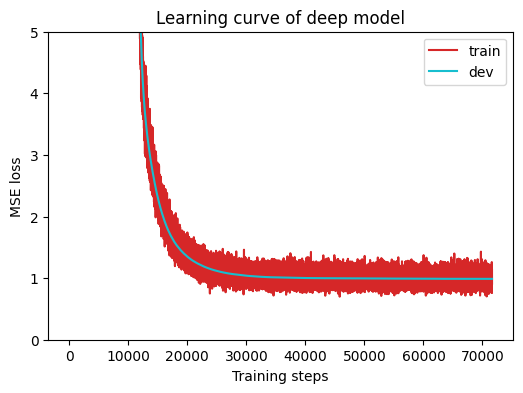

In [442]:
plot_learning_curve(model_loss_record, title='deep model')

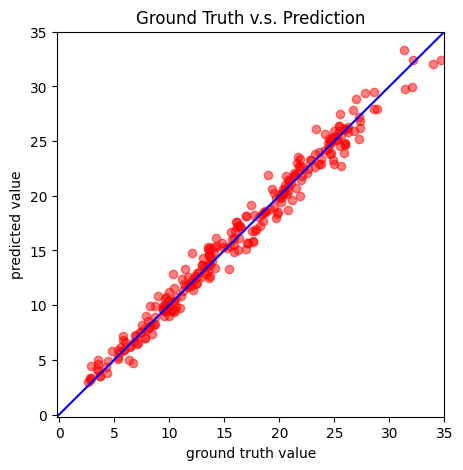

In [443]:
del model
model = NeuralNet(tr_set.dataset.dim).to(config['device'])
ckpt = torch.load(config['save_path'], map_location='cpu')  # Load your best model
model.load_state_dict(ckpt)
plot_pred(dv_set, model, config['device'])  # Show prediction on the validation set

In [444]:
# 9.定义获取结果函数
def get_result(tt_set,model,device) -> np.ndarray:
    model.eval()
    preds = []
    for x in tt_set:
        x = x.to(device)
        with torch.no_grad():
            pred = model(x)
            preds.append(pred.detach().cpu())
    preds = torch.cat(preds,dim=0).numpy()
    return preds


In [445]:
#10.保存答案
def save_result(preds,save_path):
    with open(save_path,'w') as f:
        f.write('id,tested_positive\n')
        for i,pred in enumerate(preds):
            f.write(f'{i},{pred}\n')

            


In [446]:
preds = get_result(tt_set,model,config['device'])

save_result(preds,'submission.csv')